# CSI4142 – Assignment 4: Unsupervised Learning & Recommendations

**Group Number:** [102]

**Team Members:**
* Suryadev Andotra [300006733]
* Ryan Jiayan Guo [300294370]

**Work Split:**
* **Suryadev:** Dataset description, Data Preparation Movies Dataset (EDA, cleaning), Study 1 (Similarity Measures), and Study 3 (Content-Based Recommendations).
* **Ryan Jiayan Guo:** Data Preparation Amazon Apparels Dataset (EDA, cleaning), Study 2 (Clustering algorithms), and Study 4 (Collaborative Filtering).


## 0. Imports and Setup

In [56]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import ast
import warnings
warnings.filterwarnings('ignore')

from scipy.spatial.distance import euclidean, cityblock
from sklearn.preprocessing import MinMaxScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import mean_squared_error

# For text similarity
import Levenshtein

pd.set_option('display.max_columns', 20)
pd.set_option('display.max_colwidth', 40)


## 1. Dataset Description

**Dataset 1:** The Movies Dataset  
**Source:** [Kaggle – The Movies Dataset](https://www.kaggle.com/datasets/rounakbanik/the-movies-dataset)  
**Author:** Rounak Banik  
**Purpose:** Compiled from TMDB and GroupLens; contains metadata for 45,000+ movies along with 26 million ratings from 270,000+ users.

**Key files:**
- `movies_metadata.csv` – movie metadata (budget, genres, revenue, runtime, title, etc.)
- `ratings_small.csv` – 100,000 ratings from 700 users on 9,000 movies

**Features of `movies_metadata.csv` (selected):**

| Feature | Type | Description |
|---|---|---|
| `title` | Text | Movie title |
| `genres` | JSON / Categorical | List of genre dicts |
| `budget` | Numerical | Production budget (USD) |
| `revenue` | Numerical | Box-office revenue (USD) |
| `runtime` | Numerical | Duration in minutes |
| `popularity` | Numerical | TMDB popularity score |
| `vote_average` | Numerical | Average user rating (0–10) |
| `release_date` | Date | Release date |
| `overview` | Text | Plot summary |
| `id` | Numerical | TMDB movie ID |

**Features of `ratings_small.csv`:**

| Feature | Type | Description |
|---|---|---|
| `userId` | Numerical | Unique user identifier |
| `movieId` | Numerical | Movie identifier (links to `id` in metadata) |
| `rating` | Numerical | User rating (0.5–5.0) |
| `timestamp` | Numerical | Unix timestamp of the rating |

---

**Dataset 2:** Amazon Apparels Data Review  
**Source:** [Kaggle – Amazon Apparel Reviews](https://www.kaggle.com/datasets)  
**Author:** nicapotato  
**Purpose:** Contains product metadata and individual user reviews for clothing items on Amazon, representative of messy real-world e-commerce data.

**Key files:**
- `Amazon-clothing-info.csv` – product metadata
- `Clothing-Reviews.csv` – individual user reviews; the `asin` field links reviews to product metadata

**Features of `Amazon-clothing-info.csv`:**

| Feature | Type | Description |
|---|---|---|
| `sku` | Text | Stock Keeping Unit identifier |
| `asin` | Text | Amazon Standard Identification Number (product ID) |
| `product_type_name` | Categorical | Product type category |
| `formatted_price` | Text / Numerical | Listed price (as formatted string) |
| `author` | Text | Author / designer |
| `color` | Categorical | Product color |
| `brand` | Categorical | Brand name |
| `publisher` | Text | Publisher |
| `availability` | Categorical | Stock availability status |
| `reviews` | Text | Review snippet |
| `large_image_url` | Text | URL to large product image |
| `availability_type` | Categorical | Availability classification |
| `small_image_url` | Text | URL to small product image |
| `editorial_review` | Text | Editorial description of the product |
| `title` | Text | Product title / name |
| `model` | Text | Model number |
| `medium_image_url` | Text | URL to medium product image |
| `manufacturer` | Categorical | Manufacturer name |
| `editorial_reivew` | Text | Duplicate editorial review column (typo in source) |

**Features of `Clothing-Reviews.csv`:**

| Feature | Type | Description |
|---|---|---|
| `asin` | Text | Product ID (links to clothing-info) |
| `title` | Text | Product title |
| `review_userId` | Text | Unique reviewer identifier |
| `review_score` | Numerical | User rating (1–5) |
| `review_summary` | Text | Short review headline |
| `review_text` | Text | Full written review content |

---

**Why we chose these datasets:** The Movies Dataset has a good mix of numerical (budget, revenue, runtime), categorical (genres), and text (title) attributes, making it easy to test different similarity measures, clustering, and recommendations. The `ratings_small.csv` file gives us individual user ratings needed for collaborative filtering. We also load the Amazon Apparels dataset as a secondary reference since it is messier and has more missing values, offering a contrast to the cleaner Movies Dataset. Neither dataset was used in our previous assignments.

### 1.1 Load the Data

In [57]:
# Load data directly from GitHub repository

# --- Movies Dataset ---
METADATA_URL = "https://raw.githubusercontent.com/Sandotra/CSI4142-Assignment4-2026/refs/heads/main/movies_metadata.csv"
RATINGS_URL  = "https://raw.githubusercontent.com/Sandotra/CSI4142-Assignment4-2026/refs/heads/main/ratings_small.csv"

meta_df = pd.read_csv(METADATA_URL, low_memory=False)
ratings_df = pd.read_csv(RATINGS_URL)

print("Movies Metadata shape:", meta_df.shape)
print("Ratings shape:        ", ratings_df.shape)

# --- Amazon Clothing Dataset ---
CLOTHING_INFO_URL = "https://raw.githubusercontent.com/Sandotra/CSI4142-Assignment4-2026/refs/heads/main/Amazon-clothing-info.csv"
CLOTHING_REVIEWS_URL = "https://raw.githubusercontent.com/Sandotra/CSI4142-Assignment4-2026/refs/heads/main/Clothing-Reviews.csv"

clothing_df = pd.read_csv(CLOTHING_INFO_URL)
reviews_df = pd.read_csv(CLOTHING_REVIEWS_URL)

print("\nClothing Info shape:  ", clothing_df.shape)
print("Clothing Reviews shape:", reviews_df.shape)

Movies Metadata shape: (45466, 24)
Ratings shape:         (100004, 4)

Clothing Info shape:   (28395, 19)
Clothing Reviews shape: (50046, 6)


In [58]:
meta_df.head(3)

,adult,belongs_to_collection,budget,genres,homepage,id,imdb_id,original_language,original_title,overview,...,release_date,revenue,runtime,spoken_languages,status,tagline,title,video,vote_average,vote_count
0,False,"{'id': 10194, 'name': 'Toy Story Col...",30000000,"[{'id': 16, 'name': 'Animation'}, {'...",http://toystory.disney.com/toy-story,862,tt0114709,en,Toy Story,"Led by Woody, Andy's toys live happi...",...,1995-10-30,373554033.0,81.0,"[{'iso_639_1': 'en', 'name': 'Englis...",Released,NaN,Toy Story,False,7.7,5415.0
1,False,NaN,65000000,"[{'id': 12, 'name': 'Adventure'}, {'...",NaN,8844,tt0113497,en,Jumanji,When siblings Judy and Peter discove...,...,1995-12-15,262797249.0,104.0,"[{'iso_639_1': 'en', 'name': 'Englis...",Released,Roll the dice and unleash the excite...,Jumanji,False,6.9,2413.0
2,False,"{'id': 119050, 'name': 'Grumpy Old M...",0,"[{'id': 10749, 'name': 'Romance'}, {...",NaN,15602,tt0113228,en,Grumpier Old Men,A family wedding reignites the ancie...,...,1995-12-22,0.0,101.0,"[{'iso_639_1': 'en', 'name': 'Englis...",Released,Still Yelling. Still Fighting. Still...,Grumpier Old Men,False,6.5,92.0


In [59]:
ratings_df.head(3)

,userId,movieId,rating,timestamp
0,1,31,2.5,1260759144
1,1,1029,3.0,1260759179
2,1,1061,3.0,1260759182


In [60]:
clothing_df.head(3)

,sku,asin,product_type_name,formatted_price,author,color,brand,publisher,availability,reviews,large_image_url,availability_type,small_image_url,editorial_review,title,model,medium_image_url,manufacturer,editorial_reivew
0,NaN,B004GSI2OS,SHIRT,$26.26,NaN,Onyx Black/ Stone,FeatherLite,NaN,Usually ships in 6-10 business days,"[False, 'https://www.amazon.com/revi...",https://images-na.ssl-images-amazon....,now,https://images-na.ssl-images-amazon....,NaN,Featherlite Ladies' Long Sleeve Stai...,NaN,https://images-na.ssl-images-amazon....,NaN,NaN
1,NaN,B012YX2ZPI,SHIRT,$9.99,NaN,White,HX-Kingdom Fashion T-shirts,NaN,Usually ships in 4-5 business days,"[False, 'https://www.amazon.com/revi...",https://images-na.ssl-images-amazon....,now,https://images-na.ssl-images-amazon....,This Personalized Special Olympics W...,Women's Unique 100% Cotton T - Speci...,NaN,https://images-na.ssl-images-amazon....,NaN,NaN
2,NaN,B001LOUGE4,SHIRT,$11.99,NaN,Black,Fitness Etc.,NaN,NaN,"[False, 'https://www.amazon.com/revi...",https://images-na.ssl-images-amazon....,NaN,https://images-na.ssl-images-amazon....,Light Weight 2x1 Boy Beater Tank Top...,Ladies Cotton Tank 2x1 Ribbed Tank Top,NaN,https://images-na.ssl-images-amazon....,NaN,NaN


In [61]:
reviews_df.head(3)

,asin,title,review_userId,review_score,review_summary,review_text
0,B004GSI2OS,Featherlite Ladies' Long Sleeve Stai...,A174NPQZ1EABX1,5,"Fundamental of death metal, do not miss",A roaring onslaught of streaming sou...
1,B004GSI2OS,Featherlite Ladies' Long Sleeve Stai...,A17ZI8VKZJFOV8,5,Great Classic,One of incantations best recordings....
2,B004GSI2OS,Featherlite Ladies' Long Sleeve Stai...,A2F9LXG1QEJ855,4,Very Original Debut of one of the mo...,"This is an early, and rough-sounding..."


## 2. Data Preparation (EDA & Cleaning)

We perform the following preparation steps:
1. Parse the `genres` JSON column into a usable list.
2. Convert `budget`, `id`, and `revenue` to numeric (some rows contain bad data).
3. Handle missing values in `runtime`, `budget`, `revenue`.
4. Remove duplicates and obviously corrupt rows.


### 2.1 – Parse genres from JSON strings to lists of genre names

In [62]:
# 2.1 – Parse genres from JSON strings to lists of genre names
def parse_genres(x):
    try:
        return [d['name'] for d in ast.literal_eval(x)]
    except (ValueError, TypeError):
        return []

meta_df['genre_list'] = meta_df['genres'].apply(parse_genres)
meta_df['genre_str'] = meta_df['genre_list'].apply(lambda g: ', '.join(g))
meta_df.head(3)[['title','genre_list','genre_str']]


,title,genre_list,genre_str
0,Toy Story,"[Animation, Comedy, Family]","Animation, Comedy, Family"
1,Jumanji,"[Adventure, Fantasy, Family]","Adventure, Fantasy, Family"
2,Grumpier Old Men,"[Romance, Comedy]","Romance, Comedy"


### 2.2 – Convert numeric columns

In [63]:
# 2.2 – Convert numeric columns; coerce errors to NaN
for col in ['budget', 'id', 'revenue', 'runtime', 'popularity']:
    meta_df[col] = pd.to_numeric(meta_df[col], errors='coerce')

meta_df['id'] = meta_df['id'].astype('Int64')  # nullable int
print("Dtypes after conversion:")
meta_df[['budget','revenue','runtime','popularity','id']].dtypes


Dtypes after conversion:


budget        float64
revenue       float64
runtime       float64
popularity    float64
id              Int64
dtype: object

### 2.3 – Missing Value Analysis

In [64]:
# 2.3 – Missing Value Analysis
print("Missing values in movies metadata (top features):")
missing = meta_df[['title','genres','budget','revenue','runtime','popularity',
                    'vote_average','release_date','overview']].isnull().sum().sort_values(ascending=False)
print(missing)
print(f"\nTotal rows: {len(meta_df)}")
print(f"\nPercentage missing:")
print((meta_df[['title','runtime','budget','revenue','popularity','overview']].isnull().mean() * 100).round(2))

Missing values in movies metadata (top features):
overview        954
runtime         263
release_date     87
title             6
revenue           6
vote_average      6
popularity        6
budget            3
genres            0
dtype: int64

Total rows: 45466

Percentage missing:
title         0.01
runtime       0.58
budget        0.01
revenue       0.01
popularity    0.01
overview      2.10
dtype: float64


### 2.4 – Descriptive Statistics

In [65]:
# 2.4 – Descriptive Statistics
meta_df[['budget','revenue','runtime','popularity','vote_average']].describe().round(2)

,budget,revenue,runtime,popularity,vote_average
count,4.546300e+04,4.546000e+04,45203.00,45460.00,45460.00
mean,4.224579e+06,1.120935e+07,94.13,2.92,5.62
std,1.742413e+07,6.433225e+07,38.41,6.01,1.92
min,0.000000e+00,0.000000e+00,0.00,0.00,0.00
25%,0.000000e+00,0.000000e+00,85.00,0.39,5.00
50%,0.000000e+00,0.000000e+00,95.00,1.13,6.00
75%,0.000000e+00,0.000000e+00,107.00,3.68,6.80
max,3.800000e+08,2.787965e+09,1256.00,547.49,10.00


The descriptive statistics reveal large ranges for budget and revenue (both spanning from 0 to hundreds of millions), which confirms the need for normalisation when computing similarity measures later. The mean runtime is around 90–100 minutes, and popularity is heavily right-skewed.

### 2.5 – Outlier Detection

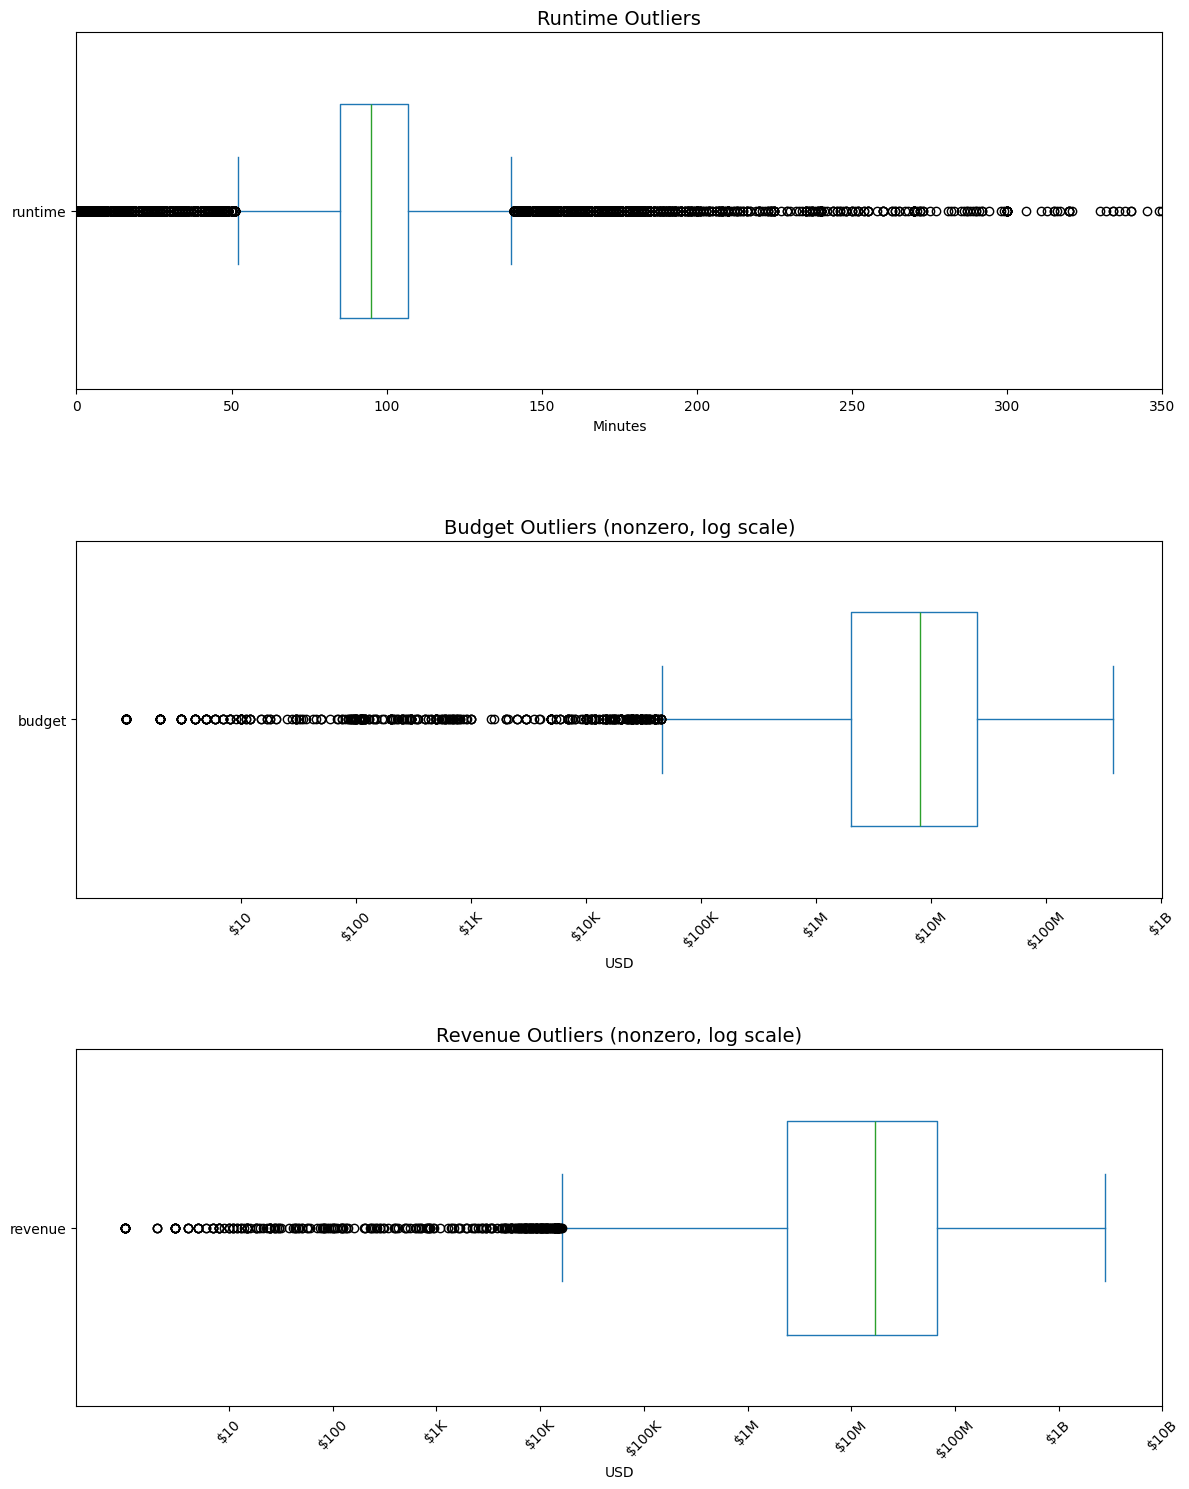

Runtime outliers (IQR method): 5417 movies
Range of outlier runtimes: 0 – 1256 minutes


In [66]:
# 2.5 – Outlier Detection
meta_df['budget'] = pd.to_numeric(meta_df['budget'], errors='coerce')
meta_df['revenue'] = pd.to_numeric(meta_df['revenue'], errors='coerce')

fig, axes = plt.subplots(3, 1, figsize=(12, 15))

# Runtime - linear scale is fine
meta_df['runtime'].dropna().plot.box(ax=axes[0], vert=False, widths=0.6)
axes[0].set_title('Runtime Outliers', fontsize=14)
axes[0].set_xlabel('Minutes')
axes[0].set_xlim(0, 350)

# Budget - log scale
meta_df[meta_df['budget'] > 0]['budget'].apply(np.log10).plot.box(ax=axes[1], vert=False, widths=0.6)
axes[1].set_title('Budget Outliers (nonzero, log scale)', fontsize=14)
axes[1].set_xlabel('USD')
axes[1].set_xticks([1, 2, 3, 4, 5, 6, 7, 8, 9])
axes[1].set_xticklabels(['$10', '$100', '$1K', '$10K', '$100K', '$1M', '$10M', '$100M', '$1B'])
axes[1].tick_params(axis='x', rotation=45)

# Revenue - log scale
meta_df[meta_df['revenue'] > 0]['revenue'].apply(np.log10).plot.box(ax=axes[2], vert=False, widths=0.6)
axes[2].set_title('Revenue Outliers (nonzero, log scale)', fontsize=14)
axes[2].set_xlabel('USD')
axes[2].set_xticks([1, 2, 3, 4, 5, 6, 7, 8, 9, 10])
axes[2].set_xticklabels(['$10', '$100', '$1K', '$10K', '$100K', '$1M', '$10M', '$100M', '$1B', '$10B'])
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout(h_pad=4)
plt.show()

# IQR-based outlier count for runtime
runtime_q1 = meta_df['runtime'].quantile(0.25)
runtime_q3 = meta_df['runtime'].quantile(0.75)
runtime_iqr = runtime_q3 - runtime_q1
runtime_outliers = meta_df[(meta_df['runtime'] < runtime_q1 - 1.5 * runtime_iqr) | 
                           (meta_df['runtime'] > runtime_q3 + 1.5 * runtime_iqr)]
print(f"Runtime outliers (IQR method): {len(runtime_outliers)} movies")
print(f"Range of outlier runtimes: {runtime_outliers['runtime'].min():.0f} – {runtime_outliers['runtime'].max():.0f} minutes")

In [67]:
# Compute exact outlier boundaries for all three features
for col, label, filter_zero in [('runtime', 'Runtime (minutes)', False), 
                                 ('budget', 'Budget (USD)', True), 
                                 ('revenue', 'Revenue (USD)', True)]:
    data = meta_df[meta_df[col] > 0][col].dropna() if filter_zero else meta_df[col].dropna()
    q1 = data.quantile(0.25)
    q3 = data.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    n_outliers = ((data < lower) | (data > upper)).sum()
    print(f"{label}:")
    print(f"  Q1 = {q1:,.0f}  |  Q3 = {q3:,.0f}  |  IQR = {iqr:,.0f}")
    print(f"  Lower fence = {lower:,.0f}  |  Upper fence = {upper:,.0f}")
    print(f"  Outliers: {n_outliers} ({n_outliers/len(data)*100:.1f}%)")
    print()

Runtime (minutes):
  Q1 = 85  |  Q3 = 107  |  IQR = 22
  Lower fence = 52  |  Upper fence = 140
  Outliers: 5417 (12.0%)

Budget (USD):
  Q1 = 2,000,000  |  Q3 = 25,000,000  |  IQR = 23,000,000
  Lower fence = -32,500,000  |  Upper fence = 59,500,000
  Outliers: 930 (10.5%)

Revenue (USD):
  Q1 = 2,400,000  |  Q3 = 67,227,070  |  IQR = 64,827,070
  Lower fence = -94,840,606  |  Upper fence = 164,467,676
  Outliers: 838 (11.3%)



The boxplots and IQR analysis reveal the following outlier patterns:

- **Runtime:** Q1 = 85 min, Q3 = 107 min (IQR = 22 min). Outliers appear below 52 minutes and above 140 minutes, accounting for 5,417 movies (12.0% of data). This means both very short films and lengthy epics are flagged.
- **Budget:** Q1 = 2M USD, Q3 = 25M USD (IQR = 23M USD). The lower fence is negative (–32.5M USD), so there are no low-end outliers — all 930 outliers (10.5%) are high-budget films exceeding 59.5M USD. This confirms what the boxplot shows: the circles on the left are low-value entries within the whiskers, while blockbusters above roughly 60M USD drive the skew.
- **Revenue:** Q1 = 2.4M USD, Q3 = 67.2M USD (IQR = 64.8M USD). Similarly, the lower fence is negative, so all 838 outliers (11.3%) are upper-end films exceeding 164.5M USD.

We retain all outliers since they represent real movies, but this skewness — particularly for budget and revenue where roughly 10% of entries are upper-end outliers — motivates our use of normalised differences in the similarity computations.

### 2.6 – Drop rows with missing title or runtime

In [68]:
# 2.6 – Drop rows with missing title or runtime
print(f"Before cleaning: {len(meta_df)} rows")
meta_df = meta_df.dropna(subset=['title', 'runtime'])
meta_df = meta_df[meta_df['runtime'] > 0]
# Remove zero-budget/revenue where they are clearly data errors for known big movies
# but keep zeros for truly low-budget indie films. We'll filter as needed per study.
print(f"After cleaning:  {len(meta_df)} rows")


Before cleaning: 45466 rows
After cleaning:  43645 rows


### 2.7 – Quick EDA: distributions

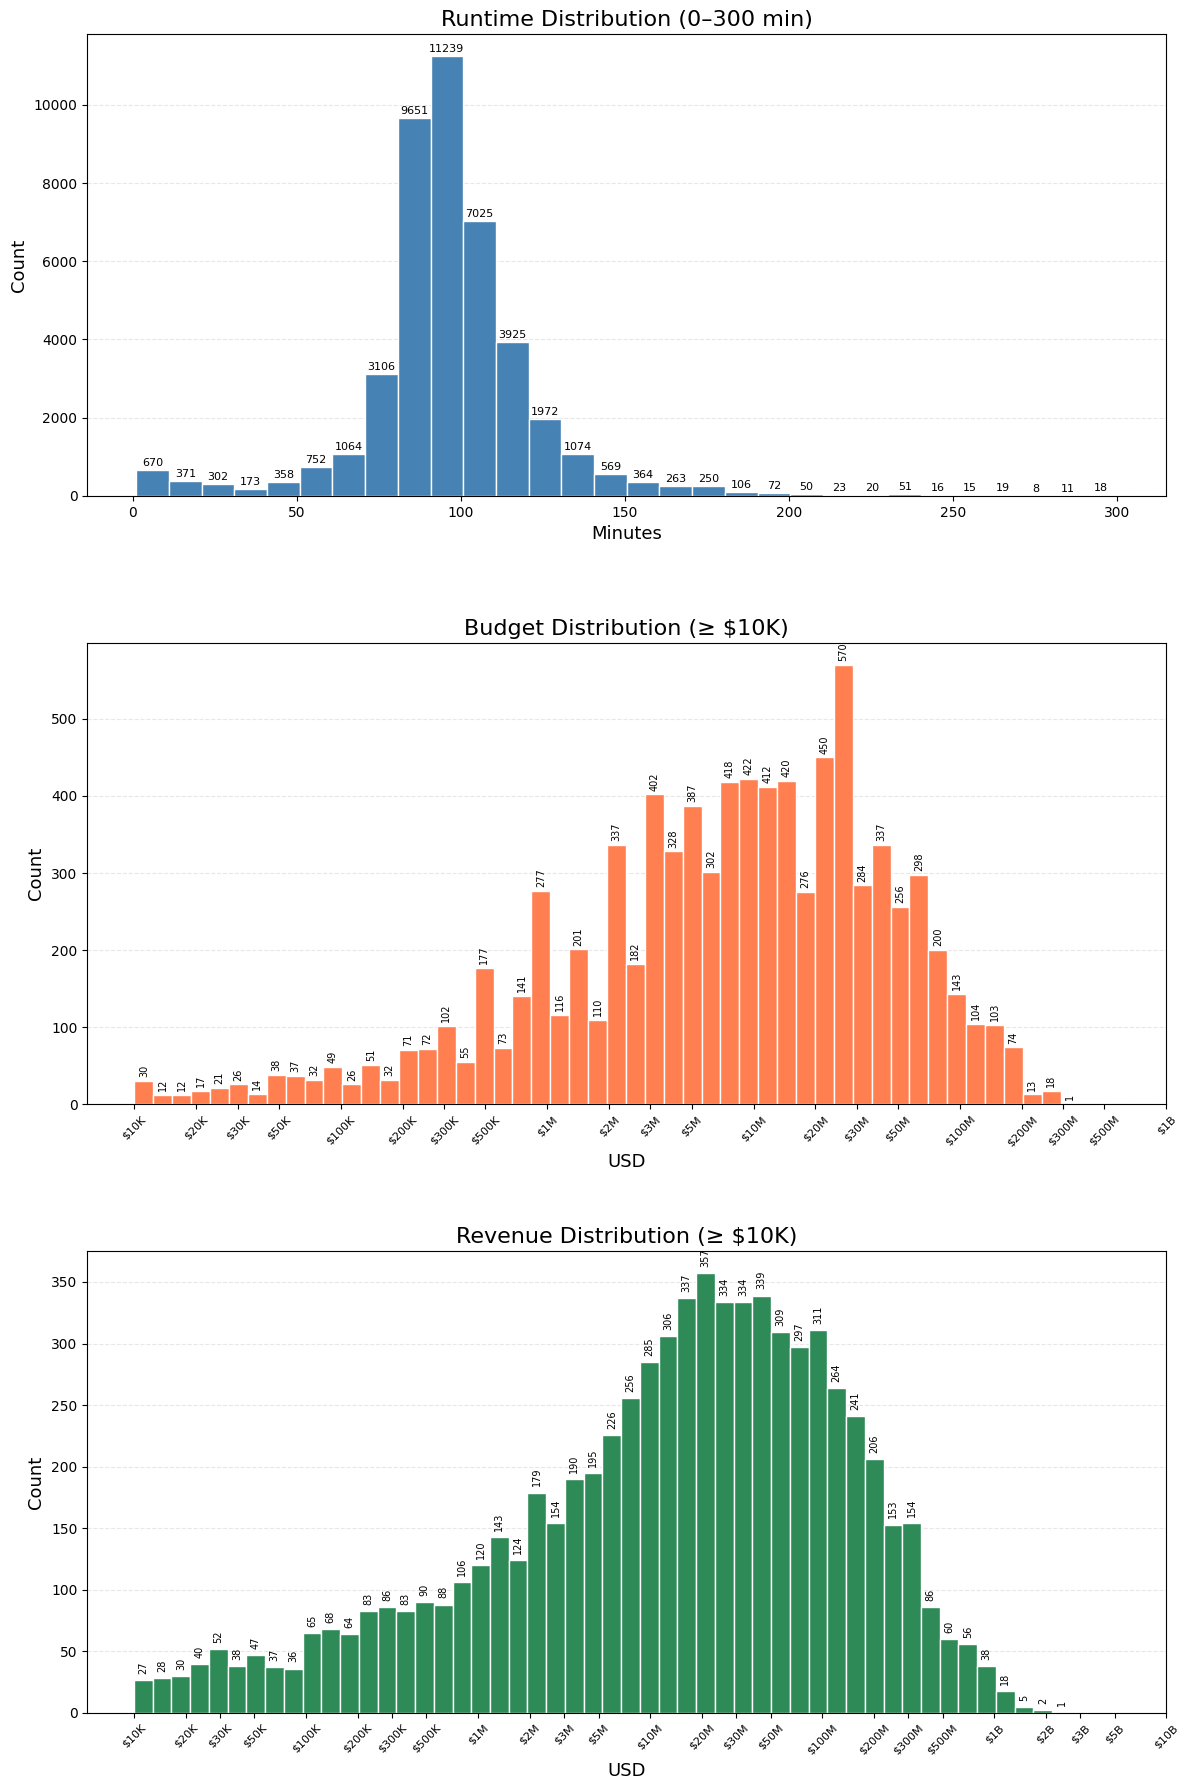

In [69]:
# 2.7 – Quick EDA: distributions
fig, axes = plt.subplots(3, 1, figsize=(12, 18))

# Runtime - use linear scale, zoomed into 0-300 range
runtime_filtered = meta_df[(meta_df['runtime'] > 0) & (meta_df['runtime'] <= 300)]
counts0, bins0, patches0 = axes[0].hist(runtime_filtered['runtime'], bins=30, color='steelblue', edgecolor='white')
axes[0].set_title('Runtime Distribution (0–300 min)', fontsize=16)
axes[0].set_xlabel('Minutes', fontsize=13)
axes[0].set_ylabel('Count', fontsize=13)
for count, patch in zip(counts0, patches0):
    if count > 0:
        axes[0].text(patch.get_x() + patch.get_width()/2, count + 50, int(count), ha='center', va='bottom', fontsize=8)

# Budget (>= $10K)
budget_filtered = meta_df[meta_df['budget'] >= 10000]
counts1, bins1, patches1 = axes[1].hist(np.log10(budget_filtered['budget']), bins=50, color='coral', edgecolor='white')
axes[1].set_title('Budget Distribution (≥ $10K)', fontsize=16)
axes[1].set_xlabel('USD', fontsize=13)
axes[1].set_ylabel('Count', fontsize=13)
axes[1].set_xticks([4, 4.3, 4.5, 4.7, 5, 5.3, 5.5, 5.7, 6, 6.3, 6.5, 6.7, 7, 7.3, 7.5, 7.7, 8, 8.3, 8.5, 8.7, 9])
axes[1].set_xticklabels(['$10K', '$20K', '$30K', '$50K', '$100K', '$200K', '$300K', '$500K', '$1M', '$2M', '$3M', '$5M', '$10M', '$20M', '$30M', '$50M', '$100M', '$200M', '$300M', '$500M', '$1B'], fontsize=8, rotation=45)
for count, patch in zip(counts1, patches1):
    if count > 0:
        axes[1].text(patch.get_x() + patch.get_width()/2, count + 5, int(count), ha='center', va='bottom', fontsize=7, rotation=90)

# Revenue (>= $10K)
revenue_filtered = meta_df[meta_df['revenue'] >= 10000]
counts2, bins2, patches2 = axes[2].hist(np.log10(revenue_filtered['revenue']), bins=50, color='seagreen', edgecolor='white')
axes[2].set_title('Revenue Distribution (≥ $10K)', fontsize=16)
axes[2].set_xlabel('USD', fontsize=13)
axes[2].set_ylabel('Count', fontsize=13)
axes[2].set_xticks([4, 4.3, 4.5, 4.7, 5, 5.3, 5.5, 5.7, 6, 6.3, 6.5, 6.7, 7, 7.3, 7.5, 7.7, 8, 8.3, 8.5, 8.7, 9, 9.3, 9.5, 9.7, 10])
axes[2].set_xticklabels(['$10K', '$20K', '$30K', '$50K', '$100K', '$200K', '$300K', '$500K', '$1M', '$2M', '$3M', '$5M', '$10M', '$20M', '$30M', '$50M', '$100M', '$200M', '$300M', '$500M', '$1B', '$2B', '$3B', '$5B', '$10B'], fontsize=8, rotation=45)
for count, patch in zip(counts2, patches2):
    if count > 0:
        axes[2].text(patch.get_x() + patch.get_width()/2, count + 5, int(count), ha='center', va='bottom', fontsize=7, rotation=90)

for ax in axes:
    ax.yaxis.grid(True, alpha=0.3, linestyle='--')
    ax.set_axisbelow(True)

plt.tight_layout(h_pad=4)
plt.show()

### 2.8 – EDA: Top 10 most common genres

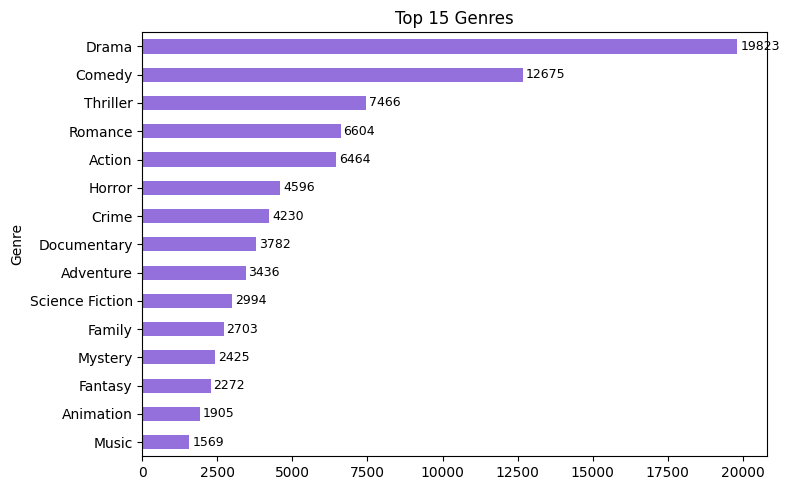

In [70]:
# 2.8 – EDA: Top 10 most common genres
from collections import Counter
all_genres = [g for gl in meta_df['genre_list'] for g in gl]
genre_counts = Counter(all_genres).most_common(15)
genre_df = pd.DataFrame(genre_counts, columns=['Genre','Count'])
ax = genre_df.plot.barh(
    x='Genre', y='Count', figsize=(8,5), title='Top 15 Genres', legend=False, color='mediumpurple')
plt.gca().invert_yaxis()

for idx, count in enumerate(genre_df['Count']):
    ax.text(count + 100, idx, str(count), va='center', fontsize=9)

plt.tight_layout()
plt.show()

### 2.9 – EDA: Ratings distribution

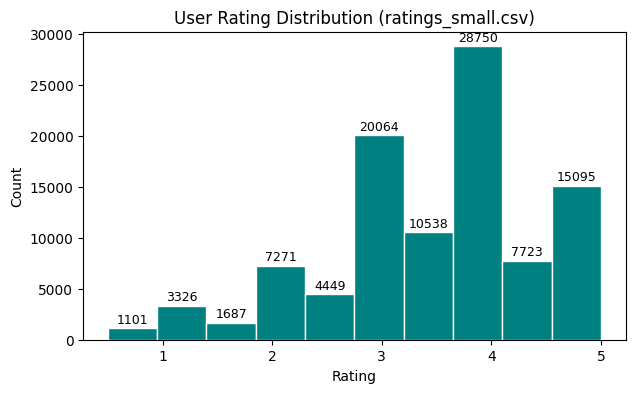

In [71]:
# 2.9 – EDA: Ratings distribution
fig, ax = plt.subplots(figsize=(7,4))
counts, bins, patches = ax.hist(ratings_df['rating'], bins=10, color='teal', edgecolor='white')

for count, patch in zip(counts, patches):
    ax.text(patch.get_x() + patch.get_width()/2, count + 200, int(count), ha='center', va='bottom', fontsize=9)

ax.set_title('User Rating Distribution (ratings_small.csv)')
ax.set_xlabel('Rating')
ax.set_ylabel('Count')
plt.show()

## Study 1 – Similarity Measures

We pick **5 attributes** and apply a different similarity measure to each:

| # | Attribute | Similarity Measure | Type |
|---|---|---|---|
| 1 | `genre_list` | **Jaccard Similarity** | Categorical (set-based) |
| 2 | `revenue` | **Euclidean Distance** | Numerical |
| 3 | `runtime` | **Manhattan Distance** | Numerical |
| 4 | `title` | **Levenshtein (Edit) Distance** | Text-based |
| 5 | `budget` | **Cosine Similarity** | Numerical |

For each query we return the **Top 10** results ranked by **popularity** (descending) among the most similar items.


In [72]:
# ── Helper: prepare a clean working copy for Study 1 ──
study_df = meta_df[['id','title','genre_list','genre_str','budget','revenue',
                     'runtime','popularity','vote_average']].copy()
study_df = study_df.dropna(subset=['title','runtime','popularity'])
study_df = study_df.drop_duplicates(subset='title', keep='first').reset_index(drop=True)
print(f"Study 1 working set: {len(study_df)} movies")
study_df.head()


Study 1 working set: 40570 movies


,id,title,genre_list,genre_str,budget,revenue,runtime,popularity,vote_average
0,862,Toy Story,"[Animation, Comedy, Family]","Animation, Comedy, Family",30000000.0,373554033.0,81.0,21.946943,7.7
1,8844,Jumanji,"[Adventure, Fantasy, Family]","Adventure, Fantasy, Family",65000000.0,262797249.0,104.0,17.015539,6.9
2,15602,Grumpier Old Men,"[Romance, Comedy]","Romance, Comedy",0.0,0.0,101.0,11.712900,6.5
3,31357,Waiting to Exhale,"[Comedy, Drama, Romance]","Comedy, Drama, Romance",16000000.0,81452156.0,127.0,3.859495,6.1
4,11862,Father of the Bride Part II,[Comedy],Comedy,0.0,76578911.0,106.0,8.387519,5.7


In [73]:
# ── Similarity functions ──

# 1. Jaccard similarity on genre sets
def jaccard_sim(set_a, set_b):
    a, b = set(set_a), set(set_b)
    if not a and not b:
        return 1.0
    inter = len(a & b)
    union = len(a | b)
    return inter / union if union else 0.0

# 2. Euclidean distance (lower = more similar)
def euclidean_sim(val_a, val_b):
    return abs(val_a - val_b)

# 3. Manhattan distance
def manhattan_sim(val_a, val_b):
    return abs(val_a - val_b)

# 4. Levenshtein (Edit) distance on strings
def edit_distance_sim(str_a, str_b):
    return Levenshtein.distance(str_a.lower(), str_b.lower())

# 5. Cosine similarity (for a single numeric dimension, we normalise against a reference)
def cosine_sim_1d(val_a, val_b):
    # Treat as 1-D vectors; cosine = (a·b)/(|a||b|)
    if val_a == 0 or val_b == 0:
        return 0.0
    return (val_a * val_b) / (abs(val_a) * abs(val_b))  # always 1 or -1 for 1-D; 

# More useful 1-D cosine proxy:
def cosine_proxy(val_a, val_b):
    denom = max(abs(val_a), abs(val_b), 1)
    return 1.0 - abs(val_a - val_b) / denom


In [74]:
# ── Generic query function ──
def query_similar(df, ref_title, attr, sim_func, top_n=10, ascending=True, display_cols=None):
    """
    Find top_n most similar movies to ref_title based on attr using sim_func.
    ascending=True means lower score = more similar (distances).
    ascending=False means higher score = more similar (similarities).
    Results are first filtered to top 3*top_n by similarity, then ranked by popularity desc.
    """
    if display_cols is None:
        display_cols = ['title','genre_str','runtime','popularity','vote_average']
    
    ref_row = df[df['title'] == ref_title]
    if ref_row.empty:
        print(f"Movie '{ref_title}' not found.")
        return pd.DataFrame()
    ref_val = ref_row.iloc[0][attr]
    
    others = df[df['title'] != ref_title].copy()
    others['sim_score'] = others[attr].apply(lambda x: sim_func(ref_val, x))
    
    # Get top candidates by similarity
    candidates = others.sort_values('sim_score', ascending=ascending).head(top_n * 3)
    # Then rank by popularity
    result = candidates.sort_values('popularity', ascending=False).head(top_n)
    
    return result[display_cols + ['sim_score']].reset_index(drop=True)


In [75]:
# ── Request 1: Movies of the same genre as "Toy Story" (Jaccard) ──
print("Request 1: Movies with similar GENRE to 'Toy Story' (Jaccard Similarity)")
print("="*80)

ref = study_df[study_df['title'] == 'Toy Story'].iloc[0]
print(f"Reference genres: {ref['genre_str']}\n")

others = study_df[study_df['title'] != 'Toy Story'].copy()
others['sim_score'] = others['genre_list'].apply(lambda g: jaccard_sim(ref['genre_list'], g))
top = others.sort_values('sim_score', ascending=False).head(30)
top = top.sort_values('popularity', ascending=False).head(10)
top[['title','genre_str','runtime','popularity','sim_score']].reset_index(drop=True)


Request 1: Movies with similar GENRE to 'Toy Story' (Jaccard Similarity)
Reference genres: Animation, Comedy, Family



,title,genre_str,runtime,popularity,sim_score
0,The Emoji Movie,"Comedy, Family, Animation",86.0,33.694599,1.0
1,Chicken Little,"Animation, Family, Comedy",81.0,18.584609,1.0
2,Toy Story 2,"Animation, Comedy, Family",92.0,17.547693,1.0
3,Cloudy with a Chance of Meatballs 2,"Animation, Family, Comedy",95.0,14.412061,1.0
4,Hotel Transylvania 2,"Animation, Comedy, Family",89.0,11.760218,1.0
5,Madly Madagascar,"Animation, Comedy, Family",22.0,11.463062,1.0
6,Meet the Robinsons,"Animation, Comedy, Family",95.0,10.529576,1.0
7,Frankenweenie,"Animation, Comedy, Family",87.0,10.296047,1.0
8,Garfield,"Animation, Comedy, Family",80.0,10.003679,1.0
9,Hoodwinked Too! Hood VS. Evil,"Comedy, Animation, Family",86.0,9.382577,1.0


In [76]:
# ── Request 2: Movies with similar revenue to "Titanic" (Euclidean) ──
print("Request 2: Movies with similar REVENUE to 'Titanic' (Euclidean Distance)")
print("="*80)

result2 = query_similar(study_df, 'Titanic', 'revenue', euclidean_sim, ascending=True)
result2


Request 2: Movies with similar REVENUE to 'Titanic' (Euclidean Distance)


,title,genre_str,runtime,popularity,vote_average,sim_score
0,Minions,"Family, Animation, Adventure, Comedy",91.0,547.488298,6.4,688303226.0
1,Captain America: Civil War,"Adventure, Action, Science Fiction",147.0,145.882135,7.1,691729693.0
2,The Dark Knight,"Drama, Action, Crime, Thriller",152.0,123.167259,8.3,840475744.0
3,The Fate of the Furious,"Action, Crime, Thriller",136.0,48.573287,6.8,606269423.0
4,Harry Potter and the Philosopher's S...,"Adventure, Fantasy, Family",152.0,38.187238,7.5,868558638.0
5,Avengers: Age of Ultron,"Action, Adventure, Science Fiction",141.0,37.379420,7.3,439630494.0
6,Despicable Me 3,"Action, Animation, Adventure, Family...",96.0,36.631519,6.2,824970804.0
7,Rogue One: A Star Wars Story,"Action, Adventure, Science Fiction",133.0,36.567575,7.4,788976915.0
8,Jurassic World,"Action, Adventure, Science Fiction, ...",124.0,32.790475,6.5,331505378.0
9,The Hobbit: The Battle of the Five A...,"Action, Adventure, Fantasy",144.0,31.718977,7.1,889014400.0


In [77]:
# ── Request 3: Movies with similar runtime to "Apollo 13" (Manhattan) ──
print("Request 3: Movies with similar RUNTIME to 'Apollo 13' (Manhattan Distance)")
print("="*80)

result3 = query_similar(study_df, 'Apollo 13', 'runtime', manhattan_sim, ascending=True)
result3


Request 3: Movies with similar RUNTIME to 'Apollo 13' (Manhattan Distance)


,title,genre_str,runtime,popularity,vote_average,sim_score
0,Triple Cross,"Action, Adventure, Thriller",140.0,10.188296,5.5,0.0
1,The Spacewalker,"Adventure, Drama, History",140.0,10.181000,7.4,0.0
2,The Tragedy of Macbeth,"War, Drama, History",140.0,4.522440,7.0,0.0
3,Heaven & Earth,"History, War, Action, Drama",140.0,4.190541,6.4,0.0
4,Sometimes in April,"Drama, History, War",140.0,3.687491,7.2,0.0
5,Nowhere in Africa,Drama,140.0,3.020270,7.0,0.0
6,Housefull 3,"Comedy, Romance",140.0,2.503800,5.2,0.0
7,The House of Mirth,"Drama, Romance",140.0,2.492547,6.4,0.0
8,They Died with Their Boots On,"Drama, Romance, War, Western",140.0,2.454775,6.1,0.0
9,Billa II,Action,140.0,2.174859,6.0,0.0


In [78]:
# ── Request 4: Movies with similar title to "Fight Club" (Edit Distance) ──
print("Request 4: Movies with similar TITLE to 'Fight Club' (Levenshtein Edit Distance)")
print("="*80)

result4 = query_similar(study_df, 'Fight Club', 'title', edit_distance_sim, ascending=True)
result4


Request 4: Movies with similar TITLE to 'Fight Club' (Levenshtein Edit Distance)


,title,genre_str,runtime,popularity,vote_average,sim_score
0,Eight Below,"Adventure, Drama, Family",120.0,13.876881,6.7,5
1,Flightplan,"Thriller, Drama, Mystery",98.0,12.419851,6.1,5
2,Fighting,"Action, Adventure, Crime, Drama, Thr...",105.0,7.036697,5.5,5
3,First Kid,"Comedy, Family",101.0,6.510437,5.3,6
4,Cougar Club,Comedy,93.0,5.556157,4.4,5
5,Flight Crew,"Drama, Action",138.0,5.420460,6.8,4
6,Flight 7500,"Thriller, Horror, Mystery",97.0,5.265969,4.3,5
7,Lights Out,Horror,3.0,4.082720,7.5,5
8,Nightfall,"Action, Crime, Thriller",78.0,3.457573,6.8,5
9,Flight 93,"Drama, Thriller, TV Movie",89.0,2.990253,6.0,5


In [79]:
# ── Request 5: Movies with similar budget to "The Matrix" (Cosine Proxy) ──
print("Request 5: Movies with similar BUDGET to 'The Matrix' (Cosine Proximity)")
print("="*80)

# Filter to movies with nonzero budget for meaningful comparison
budget_df = study_df[study_df['budget'] > 0].copy()
result5 = query_similar(budget_df, 'The Matrix', 'budget', cosine_proxy, ascending=False)
result5


Request 5: Movies with similar BUDGET to 'The Matrix' (Cosine Proximity)


,title,genre_str,runtime,popularity,vote_average,sim_score
0,Fight Club,Drama,139.0,63.869599,8.3,1.000000
1,Sin City: A Dame to Kill For,"Crime, Thriller",102.0,20.623642,6.3,0.969231
2,Zodiac,"Crime, Drama, Mystery, Thriller",157.0,19.083823,7.3,0.969231
3,300,"Action, Adventure, War",117.0,18.108408,7.0,0.969231
4,Collateral,"Drama, Crime, Thriller",120.0,13.455112,7.0,0.969231
5,World Trade Center,"Drama, History, Thriller",128.0,13.332102,5.9,1.000000
6,Spy,"Action, Comedy, Crime",120.0,13.257467,6.9,0.969231
7,The Lovely Bones,"Fantasy, Drama",136.0,12.738789,6.6,0.969231
8,This Means War,"Action, Comedy, Romance",103.0,12.366641,5.9,0.969231
9,Æon Flux,"Action, Science Fiction",93.0,12.201912,5.4,0.984127


## Study 2 – Clustering Algorithms




In [80]:
# TODO


## Study 3 – Content-Based Recommendation System

We define **2 similarity heuristics**, each combining multiple features from Study 1.

### Heuristic 1: "Genre + Runtime + Popularity"
**Rationale:** A viewer looking for something similar would likely want the same genre mix, a comparable length, and a similarly popular movie.

$$H_1 = 0.5 \times \text{Jaccard}(\text{genres}) + 0.25 \times (1 - \text{norm\_diff}(\text{runtime})) + 0.25 \times (1 - \text{norm\_diff}(\text{popularity}))$$

### Heuristic 2: "Genre + Budget + Revenue"
**Rationale:** Production scale matters — a big-budget blockbuster fan probably wants other blockbusters, not micro-budget indie films of the same genre.

$$H_2 = 0.4 \times \text{Jaccard}(\text{genres}) + 0.3 \times (1 - \text{norm\_diff}(\text{budget})) + 0.3 \times (1 - \text{norm\_diff}(\text{revenue}))$$


In [81]:
# ── Normalised difference helper ──
def norm_diff(a, b, col_max):
    """Returns value in [0,1]: 0 = identical, 1 = maximally different."""
    if col_max == 0:
        return 0.0
    return abs(a - b) / col_max

# Precompute max values for normalisation
runtime_max = study_df['runtime'].max()
pop_max = study_df['popularity'].max()
budget_max = study_df[study_df['budget'] > 0]['budget'].max()
revenue_max = study_df[study_df['revenue'] > 0]['revenue'].max()

def heuristic_1(ref, row):
    """Genre + Runtime + Popularity"""
    genre_score = jaccard_sim(ref['genre_list'], row['genre_list'])
    runtime_score = 1 - norm_diff(ref['runtime'], row['runtime'], runtime_max)
    pop_score = 1 - norm_diff(ref['popularity'], row['popularity'], pop_max)
    return 0.50 * genre_score + 0.25 * runtime_score + 0.25 * pop_score

def heuristic_2(ref, row):
    """Genre + Budget + Revenue"""
    genre_score = jaccard_sim(ref['genre_list'], row['genre_list'])
    budget_score = 1 - norm_diff(ref['budget'], row['budget'], budget_max) if ref['budget'] > 0 and row['budget'] > 0 else 0
    revenue_score = 1 - norm_diff(ref['revenue'], row['revenue'], revenue_max) if ref['revenue'] > 0 and row['revenue'] > 0 else 0
    return 0.40 * genre_score + 0.30 * budget_score + 0.30 * revenue_score

def content_recommend(df, ref_title, heuristic_fn, top_n=10):
    ref_row = df[df['title'] == ref_title]
    if ref_row.empty:
        print(f"'{ref_title}' not found"); return pd.DataFrame()
    ref = ref_row.iloc[0]
    others = df[df['title'] != ref_title].copy()
    others['h_score'] = others.apply(lambda r: heuristic_fn(ref, r), axis=1)
    top = others.sort_values('h_score', ascending=False).head(top_n)
    return top[['title','genre_str','runtime','budget','revenue','popularity','h_score']].reset_index(drop=True)


In [82]:
# ── Content-Based Request: Movies similar to "Toy Story" ──
print("Movies similar to 'Toy Story' — Heuristic 1 (Genre + Runtime + Popularity)")
print("="*80)
display(content_recommend(study_df, 'Toy Story', heuristic_1))

print("\nMovies similar to 'Toy Story' — Heuristic 2 (Genre + Budget + Revenue)")
print("="*80)
display(content_recommend(study_df, 'Toy Story', heuristic_2))


Movies similar to 'Toy Story' — Heuristic 1 (Genre + Runtime + Popularity)


,title,genre_str,runtime,budget,revenue,popularity,h_score
0,Chicken Little,"Animation, Family, Comedy",81.0,150000000.0,314432665.0,18.584609,0.998465
1,Toy Story 2,"Animation, Comedy, Family",92.0,90000000.0,497366869.0,17.547693,0.995802
2,"Monsters, Inc.","Animation, Comedy, Family",92.0,115000000.0,562816256.0,26.419962,0.995768
3,The Simpsons Movie,"Animation, Comedy, Family",87.0,75000000.0,527068851.0,14.302911,0.995315
4,Despicable Me 2,"Animation, Comedy, Family",98.0,76000000.0,970761885.0,24.823550,0.995303
5,Chicken Run,"Animation, Comedy, Family",84.0,45000000.0,224834564.0,11.834245,0.994785
6,Surf's Up,"Animation, Comedy, Family",85.0,85000000.0,149044513.0,11.526339,0.994445
7,Looney Tunes: Back in Action,"Animation, Comedy, Family",90.0,80000000.0,68514844.0,13.666488,0.994427
8,Garfield,"Animation, Comedy, Family",80.0,50000000.0,200804534.0,10.003679,0.994347
9,An Extremely Goofy Movie,"Animation, Family, Comedy",79.0,0.0,0.0,10.368424,0.994315



Movies similar to 'Toy Story' — Heuristic 2 (Genre + Budget + Revenue)


,title,genre_str,runtime,budget,revenue,popularity,h_score
0,The SpongeBob SquarePants Movie,"Animation, Comedy, Family",87.0,30000000.0,140161792.0,11.213712,0.974886
1,Chicken Run,"Animation, Comedy, Family",84.0,45000000.0,224834564.0,11.834245,0.972155
2,Oliver & Company,"Animation, Comedy, Family",74.0,31000000.0,74151346.0,10.813579,0.966993
3,Garfield,"Animation, Comedy, Family",80.0,50000000.0,200804534.0,10.003679,0.965622
4,Hoodwinked Too! Hood VS. Evil,"Comedy, Animation, Family",86.0,30000000.0,13521829.0,9.382577,0.961259
5,Over the Hedge,"Comedy, Animation, Family",83.0,80000000.0,343397247.0,9.382953,0.957281
6,Frankenweenie,"Animation, Comedy, Family",87.0,39000000.0,35287788.0,10.296047,0.956495
7,Meet the Deedles,"Animation, Comedy, Family",93.0,24000000.0,4562146.0,7.336354,0.955558
8,Hop,"Animation, Comedy, Family",95.0,63000000.0,183953723.0,8.904488,0.953545
9,Hoodwinked!,"Animation, Comedy, Family",80.0,15000000.0,51053787.0,6.398984,0.953455


In [83]:
# ── Content-Based Request: Movies similar to "Apollo 13" ──
print("Movies similar to 'Apollo 13' — Heuristic 1 (Genre + Runtime + Popularity)")
print("="*80)
display(content_recommend(study_df, 'Apollo 13', heuristic_1))

print("\nMovies similar to 'Apollo 13' — Heuristic 2 (Genre + Budget + Revenue)")
print("="*80)
display(content_recommend(study_df, 'Apollo 13', heuristic_2))


Movies similar to 'Apollo 13' — Heuristic 1 (Genre + Runtime + Popularity)


,title,genre_str,runtime,budget,revenue,popularity,h_score
0,The Judge,Drama,141.0,50000000.0,83719388.0,17.887943,0.999402
1,The Perfect Storm,Drama,130.0,120000000.0,325756637.0,18.911961,0.997941
2,Mommy,Drama,138.0,4900000.0,3494070.0,14.876086,0.997828
3,Eat Pray Love,Drama,133.0,60000000.0,204594016.0,15.904834,0.997302
4,Dead Poets Society,Drama,129.0,16400000.0,235860116.0,19.905716,0.997288
5,Moneyball,Drama,133.0,50000000.0,110206216.0,15.785663,0.997248
6,The Book Thief,Drama,131.0,0.0,76586316.0,16.373622,0.997118
7,You Don't Know Jack,Drama,134.0,0.0,0.0,14.988063,0.997083
8,Showgirls,Drama,128.0,45000000.0,20350754.0,17.502375,0.997037
9,A Few Good Men,Drama,138.0,40000000.0,243240178.0,12.330249,0.996665



Movies similar to 'Apollo 13' — Heuristic 2 (Genre + Budget + Revenue)


,title,genre_str,runtime,budget,revenue,popularity,h_score
0,The Pursuit of Happyness,Drama,117.0,55000000.0,307077295.0,20.981716,0.992449
1,Erin Brockovich,Drama,131.0,52000000.0,256271286.0,10.135446,0.989351
2,Indecent Proposal,Drama,117.0,38000000.0,266614059.0,7.118123,0.979411
3,A Few Good Men,Drama,138.0,40000000.0,243240178.0,12.330249,0.978475
4,Rocky IV,Drama,91.0,31000000.0,300473716.0,10.257210,0.977528
5,Seven Pounds,Drama,123.0,55000000.0,168167691.0,21.708267,0.977502
6,Eat Pray Love,Drama,133.0,60000000.0,204594016.0,15.904834,0.977474
7,The Blind Side,Drama,129.0,29000000.0,309208309.0,12.753109,0.976889
8,The Social Network,Drama,120.0,40000000.0,224920315.0,16.972995,0.976503
9,8 Mile,Drama,110.0,41000000.0,215000000.0,8.374355,0.976225


In [84]:
# ── Content-Based Request: Movies similar to "Fight Club" ──
print("Movies similar to 'Fight Club' — Heuristic 1 (Genre + Runtime + Popularity)")
print("="*80)
display(content_recommend(study_df, 'Fight Club', heuristic_1))

print("\nMovies similar to 'Fight Club' — Heuristic 2 (Genre + Budget + Revenue)")
print("="*80)
display(content_recommend(study_df, 'Fight Club', heuristic_2))


Movies similar to 'Fight Club' — Heuristic 1 (Genre + Runtime + Popularity)


,title,genre_str,runtime,budget,revenue,popularity,h_score
0,Whiplash,Drama,105.0,3300000.0,13092000.0,64.299990,0.993036
1,One Flew Over the Cuckoo's Nest,Drama,133.0,3000000.0,108981275.0,35.529554,0.985865
2,Creed,Drama,133.0,37000000.0,173567581.0,33.449723,0.984915
3,Apollo 13,Drama,140.0,52000000.0,355237933.0,18.761467,0.979203
4,The Judge,Drama,141.0,50000000.0,83719388.0,17.887943,0.978605
5,Dead Poets Society,Drama,129.0,16400000.0,235860116.0,19.905716,0.977934
6,The Perfect Storm,Drama,130.0,120000000.0,325756637.0,18.911961,0.977680
7,Seven Pounds,Drama,123.0,55000000.0,168167691.0,21.708267,0.977563
8,Mommy,Drama,138.0,4900000.0,3494070.0,14.876086,0.977429
9,American Beauty,Drama,122.0,15000000.0,356296601.0,20.726578,0.976916



Movies similar to 'Fight Club' — Heuristic 2 (Genre + Budget + Revenue)


,title,genre_str,runtime,budget,revenue,popularity,h_score
0,Any Given Sunday,Drama,163.0,55000000.0,100230832.0,10.571434,0.993617
1,Dragonfly,Drama,104.0,60000000.0,52322400.0,4.924078,0.992409
2,We Are Marshall,Drama,124.0,65000000.0,43545364.0,5.401746,0.992254
3,The Soloist,Drama,109.0,60000000.0,31720158.0,11.328316,0.990192
4,A Civil Action,Drama,115.0,70000000.0,56702901.0,9.353499,0.989723
5,Moneyball,Drama,133.0,50000000.0,110206216.0,15.785663,0.988730
6,Dreamgirls,Drama,134.0,70000000.0,154937680.0,7.739633,0.988654
7,The Judge,Drama,141.0,50000000.0,83719388.0,17.887943,0.987893
8,The Hurricane,Drama,146.0,50000000.0,73956241.0,5.716009,0.986843
9,Eat Pray Love,Drama,133.0,60000000.0,204594016.0,15.904834,0.986469


### Study 3 – Discussion

**Comparing the two heuristics:**

**Heuristic 1 (Genre + Runtime + Popularity)** tends to recommend movies that feel similar in terms of the viewing experience — same genre, similar length, and comparable audience reach. This makes it effective for casual viewers who want "more of the same." For example, when querying "Toy Story," Heuristic 1 surfaces other animated family films with similar runtimes and mainstream popularity.

**Heuristic 2 (Genre + Budget + Revenue)** instead emphasises production scale. It tends to surface movies that were made and marketed at a similar level, which means a query on a blockbuster like "Fight Club" will return other mid-to-high budget dramas rather than low-budget indie films of the same genre. This heuristic is better suited for users who associate movie quality with production value.

**Overlap:** Across all three queries, the two heuristics share very few movies in their Top 10 — only 1 to 2 films per query. For "Toy Story," only Chicken Run and Garfield appear in both lists. For "Apollo 13," only Eat Pray Love and A Few Good Men overlap. For "Fight Club," only The Judge is shared. This confirms that runtime/popularity and budget/revenue capture meaningfully different aspects of movie similarity.

**Which is better?** Qualitatively, Heuristic 1 produces recommendations that feel more intuitive for a general audience — genre and runtime are features that directly affect the viewing experience. Heuristic 2 is more useful as a "production profile" matcher but can surface thematically unrelated films that happened to have a similar budget — for example, querying "Fight Club" returns "Dreamgirls" and "We Are Marshall," which share little thematic connection despite similar production scales.

## Study 4 – Collaborative Filtering Recommendation System




In [85]:
# TODO


## References

1. **Movies Dataset:** Banik, R. *The Movies Dataset*. Kaggle. https://www.kaggle.com/datasets/rounakbanik/the-movies-dataset
2. **Amazon Apparels Dataset:** nicapotato. *Women's E-Commerce Clothing Reviews*. Kaggle. https://www.kaggle.com/datasets/nicapotato/womens-ecommerce-clothing-reviews
3. **Levenshtein distance:** Levenshtein, V. I. (1966). Binary codes capable of correcting deletions, insertions, and reversals. *Soviet Physics Doklady*, 10(8), 707–710. Python implementation: `python-Levenshtein` library, https://github.com/maxbachmann/Levenshtein
4. **Jaccard similarity:** Jaccard, P. (1912). The distribution of the flora in the alpine zone. *New Phytologist*, 11(2), 37–50.
5. **scikit-learn KMeans & DBSCAN:** Pedregosa, F. et al. (2011). Scikit-learn: Machine Learning in Python. *JMLR*, 12, 2825–2830. https://scikit-learn.org/stable/modules/clustering.html
6. **Matrix Factorization for Recommender Systems:** Koren, Y., Bell, R., & Volinsky, C. (2009). Matrix Factorization Techniques for Recommender Systems. *IEEE Computer*, 42(8), 30–37.
7. **CSI4142 Course Slides:** Barrière, C. (Winter 2026). *Fundamentals of Data Science*, University of Ottawa. Lecture slides on similarity measures, clustering, and recommendation systems.